# A/B-тест новой механики оплаты + SQL + автоматизация расчёта метрик

**Контекст.** В эксперименте пользователям тестовой группы предложили новую механику оплаты.  
Нужно понять, есть ли эффект, насколько он статистически значим и стоит ли выкатывать изменение на всех пользователей.

### План ноутбука

1. Загрузка и первичная проверка данных  
2. Формирование аналитической выборки  
3. Исследовательский анализ и бизнес-интерпретация  
4. Расчёт ключевых метрик: **CR**, **ARPU**, **ARPPU**  
5. Проверка статистической значимости  
6. Рекомендация по запуску новой механики  
7. SQL-решения по заданиям  
8. Функции для автоматического пересчёта метрик и графиков

<div class="note dark">
<b>Главная идея исследования:</b> в этих данных есть оплаты пользователей, которые не были активны в дни эксперимента. 
Поэтому основной анализ ниже строится на <b>активных пользователях</b> как на когорте с подтверждённым контактом с экспериментом. 
Отдельно я покажу sensitivity-check на всех пользователях.
</div>

In [1]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="talk")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 1. Загрузка данных
Для удобства ноутбук сначала ищет локальные CSV-файлы по нескольким возможным именам, 
поэтому его можно запускать и в текущей папке, и в окружении с `/mnt/data`.

In [2]:
def find_file(candidates: list[str]) -> Path:
    search_dirs = [Path.cwd(), Path("/mnt/data")]
    for directory in search_dirs:
        for candidate in candidates:
            path = directory / candidate
            if path.exists():
                return path
    raise FileNotFoundError(f"Не удалось найти файл. Проверенные варианты: {candidates}")

def read_csv_auto(path: str | Path) -> pd.DataFrame:
    # Сначала пробуем автоопределение разделителя, затем типовые варианты
    try:
        return pd.read_csv(path, sep=None, engine="python")
    except Exception:
        for sep in [",", ";", "\t"]:
            try:
                return pd.read_csv(path, sep=sep)
            except Exception:
                continue
    raise ValueError(f"Не удалось прочитать CSV-файл: {path}")

def format_percent(x: float) -> str:
    return f"{x:.2%}".replace(".", ",")

def format_money(x: float) -> str:
    return f"{x:,.2f}".replace(",", " ").replace(".", ",")

def normalize_additional_groups(df: pd.DataFrame) -> pd.DataFrame:
    renamed = {}
    for col in df.columns:
        normalized = re.sub(r"[^a-zа-я0-9]+", "", col.lower())
        if normalized in {"id", "userid", "useridid", "studentid", "stid"}:
            renamed[col] = "id"
        elif normalized in {"grp", "group", "abgroup", "testgrp", "testgroup"}:
            renamed[col] = "grp"
    df = df.rename(columns=renamed).copy()
    expected = {"id", "grp"}
    if not expected.issubset(df.columns):
        raise ValueError(
            f"После нормализации не удалось получить колонки {expected}. "
            f"Фактические колонки: {df.columns.tolist()}"
        )
    df = df.loc[:, ["id", "grp"]].copy()
    df["id"] = pd.to_numeric(df["id"], errors="raise").astype("int64")
    df["grp"] = df["grp"].astype(str).str.strip().str.upper()
    return df

file_map = {
    "groups": ["Проект_2_groups.csv", "groups.csv"],
    "groups_add": ["Проект_2_group_add.csv", "group_add.csv", "groups_add.csv"],
    "active_studs": ["Проект_2_active_studs.csv", "active_studs.csv"],
    "checks": ["Проект_2_checks.csv", "checks.csv"],
}

groups_path = find_file(file_map["groups"])
groups_add_path = find_file(file_map["groups_add"])
active_studs_path = find_file(file_map["active_studs"])
checks_path = find_file(file_map["checks"])

groups = read_csv_auto(groups_path)
groups_add = normalize_additional_groups(read_csv_auto(groups_add_path))
active_studs = read_csv_auto(active_studs_path)
checks = read_csv_auto(checks_path)

groups.head(), groups_add.head(), active_studs.head(), checks.head()

(     id grp
 0  1489   B
 1  1627   A
 2  1768   B
 3  1783   B
 4  1794   A,
         id grp
 0  5694584   B
 1  5694830   B
 2  5695057   B
 3  5698872   B
 4  5699067   B,
    student_id
 0      581585
 1     5723133
 2     3276743
 3     4238589
 4     4475369,
    student_id      rev
 0        1627 990.0000
 1        3185 690.0000
 2       25973 690.0000
 3       26280 690.0000
 4      100300 990.0000)

In [3]:
audit = pd.DataFrame(
    [
        {
            "Датасет": "groups",
            "Строк": len(groups),
            "Уникальных ID": groups["id"].nunique(),
            "Дубликатов по ID": groups.duplicated("id").sum(),
            "Колонки": ", ".join(groups.columns),
        },
        {
            "Датасет": "groups_add",
            "Строк": len(groups_add),
            "Уникальных ID": groups_add["id"].nunique(),
            "Дубликатов по ID": groups_add.duplicated("id").sum(),
            "Колонки": ", ".join(groups_add.columns),
        },
        {
            "Датасет": "active_studs",
            "Строк": len(active_studs),
            "Уникальных ID": active_studs["student_id"].nunique(),
            "Дубликатов по ID": active_studs.duplicated("student_id").sum(),
            "Колонки": ", ".join(active_studs.columns),
        },
        {
            "Датасет": "checks",
            "Строк": len(checks),
            "Уникальных ID": checks["student_id"].nunique(),
            "Дубликатов по ID": checks.duplicated("student_id").sum(),
            "Колонки": ", ".join(checks.columns),
        },
    ]
)

display(
    audit.style
    .hide(axis="index")
    .format({"Строк": "{:,.0f}", "Уникальных ID": "{:,.0f}", "Дубликатов по ID": "{:,.0f}"})
)

Датасет,Строк,Уникальных ID,Дубликатов по ID,Колонки
groups,"74,484","74,484",0,"id, grp"
groups_add,92,92,0,"id, grp"
active_studs,"8,341","8,341",0,student_id
checks,541,541,0,"student_id, rev"


## 2. Проверка качества данных и бизнес-логики

Сначала отвечаем на три практических вопроса:

1. что именно меняет файл `groups_add`;  
2. есть ли пользователи вне основной таблицы распределения по группам;  
3. есть ли оплаты без активности в дни эксперимента.

Последний пункт особенно важен: если пользователь не заходил на платформу в экспериментальный период, 
мы не можем быть уверены, что он вообще видел новый экран оплаты.

In [4]:
groups_total = pd.concat([groups, groups_add], ignore_index=True).drop_duplicates("id", keep="last")

qa_checks = pd.DataFrame(
    [
        {"Проверка": "Пользователей из groups_add нашли в active_studs", "Количество": int(groups_add["id"].isin(active_studs["student_id"]).sum())},
        {"Проверка": "Пользователей из groups_add нашли в checks", "Количество": int(groups_add["id"].isin(checks["student_id"]).sum())},
        {"Проверка": "Активных пользователей, которых нет в группах", "Количество": int((~active_studs["student_id"].isin(groups_total["id"])).sum())},
        {"Проверка": "Оплативших пользователей, которых нет в группах", "Количество": int((~checks["student_id"].isin(groups_total["id"])).sum())},
        {"Проверка": "Оплаты пользователей без активности", "Количество": int((~checks["student_id"].isin(active_studs["student_id"])).sum())},
    ]
)

display(qa_checks.style.hide(axis="index").format({"Количество": "{:,.0f}"}))

Проверка,Количество
Пользователей из groups_add нашли в active_studs,13
Пользователей из groups_add нашли в checks,1
"Активных пользователей, которых нет в группах",0
"Оплативших пользователей, которых нет в группах",0
Оплаты пользователей без активности,149


In [5]:
inactive_payers = checks.loc[~checks["student_id"].isin(active_studs["student_id"])].copy()

display(Markdown(
    f'''
<div class="note warn">
<b>Ключевое наблюдение.</b> В данных есть <b>{len(inactive_payers)}</b> оплат пользователей, 
которые не были активны в дни эксперимента.<br><br>
Это не обязательно ошибка: это могут быть автосписания, поздние списания или покупки вне анализируемого окна активности. 
Но для оценки эффекта интерфейса оплаты основную аналитику логично строить на <b>активных пользователях</b>. 
Отдельно ниже будет sensitivity-check на всех пользователях.
</div>
'''
))


<div class="note warn">
<b>Ключевое наблюдение.</b> В данных есть <b>149</b> оплат пользователей, 
которые не были активны в дни эксперимента.<br><br>
Это не обязательно ошибка: это могут быть автосписания, поздние списания или покупки вне анализируемого окна активности. 
Но для оценки эффекта интерфейса оплаты основную аналитику логично строить на <b>активных пользователях</b>. 
Отдельно ниже будет sensitivity-check на всех пользователях.
</div>


## 3. Формирование аналитической выборки

Соберём единый датафрейм с признаками:

- `grp` — группа эксперимента (`A` / `B`);
- `is_active` — пользователь заходил на платформу в дни теста;
- `revenue` — сумма оплаты;
- `is_paid` — факт оплаты.

In [6]:
def prepare_experiment_dataset(
    groups_df: pd.DataFrame,
    active_df: pd.DataFrame,
    checks_df: pd.DataFrame,
) -> pd.DataFrame:
    df = (
        groups_df.copy()
        .merge(
            active_df.rename(columns={"student_id": "id"}).assign(is_active=1),
            on="id",
            how="left",
        )
        .merge(
            checks_df.rename(columns={"student_id": "id", "rev": "revenue"}).assign(is_paid=1),
            on="id",
            how="left",
        )
    )

    df["grp"] = df["grp"].astype(str).str.strip().str.upper()
    df["is_active"] = df["is_active"].fillna(0).astype(int)
    df["is_paid"] = df["is_paid"].fillna(0).astype(int)
    df["revenue"] = df["revenue"].fillna(0.0)

    df["grp"] = pd.Categorical(df["grp"], categories=["A", "B"], ordered=True)
    return df.sort_values(["grp", "id"]).reset_index(drop=True)

experiment_df = prepare_experiment_dataset(groups_total, active_studs, checks)
active_only_df = experiment_df.query("is_active == 1").copy()

segment_df = (
    experiment_df.assign(
        segment=np.select(
            [
                (experiment_df["is_active"].eq(1) & experiment_df["is_paid"].eq(1)),
                (experiment_df["is_active"].eq(1) & experiment_df["is_paid"].eq(0)),
                (experiment_df["is_active"].eq(0) & experiment_df["is_paid"].eq(1)),
            ],
            [
                "Активные и оплатили",
                "Активные без оплаты",
                "Неактивные, но оплатили",
            ],
            default="Неактивные без оплаты",
        )
    )
    .groupby(["grp", "segment"], observed=False)
    .size()
    .reset_index(name="users")
)

display(segment_df)

,grp,segment,users
0,A,Активные без оплаты,1460
1,A,Активные и оплатили,78
2,A,Неактивные без оплаты,13126
3,A,"Неактивные, но оплатили",29
4,B,Активные без оплаты,6489
5,B,Активные и оплатили,314
6,B,Неактивные без оплаты,52960
7,B,"Неактивные, но оплатили",120


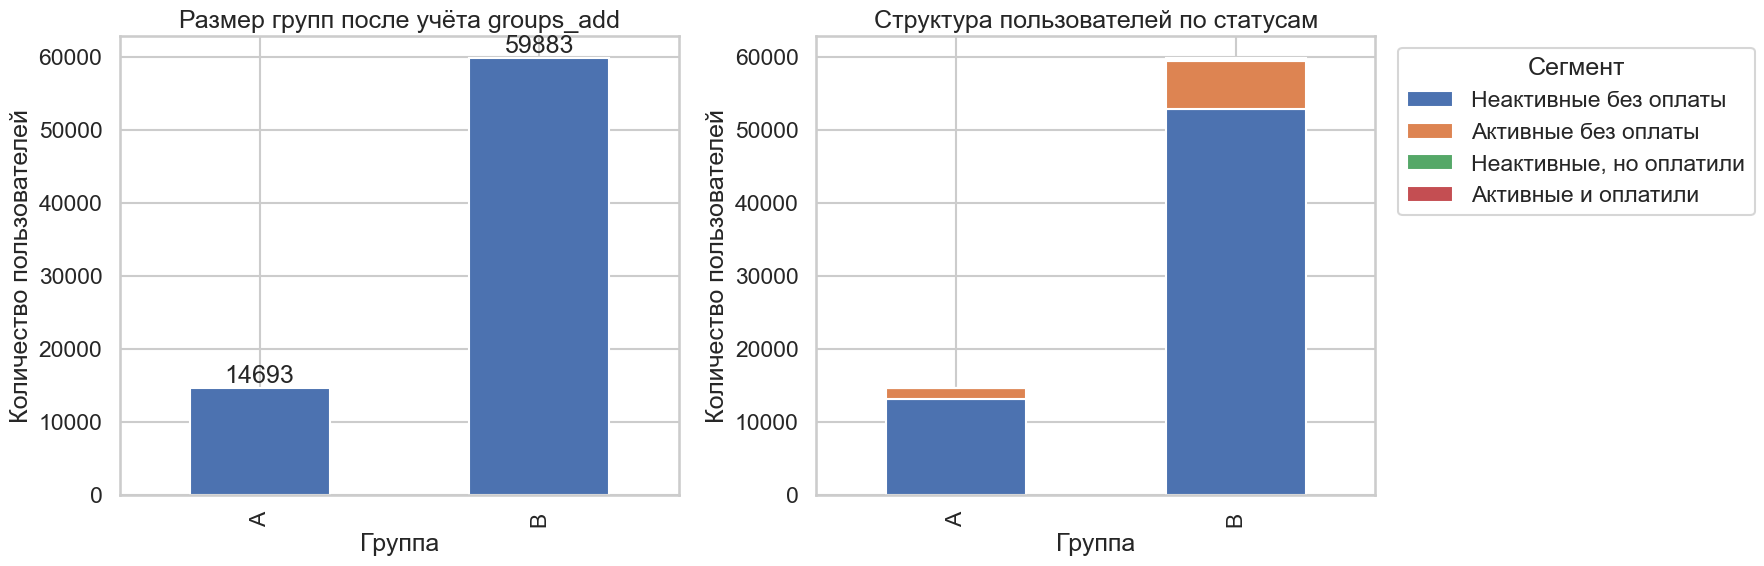

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

group_sizes = groups_total["grp"].value_counts().sort_index()
group_sizes.plot(kind="bar", ax=axes[0])
axes[0].set_title("Размер групп после учёта groups_add")
axes[0].set_xlabel("Группа")
axes[0].set_ylabel("Количество пользователей")
axes[0].bar_label(axes[0].containers[0], fmt="%.0f")

segment_pivot = (
    segment_df
    .pivot(index="grp", columns="segment", values="users")
    .reindex(index=["A", "B"])
    [["Неактивные без оплаты", "Активные без оплаты", "Неактивные, но оплатили", "Активные и оплатили"]]
)
segment_pivot.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Структура пользователей по статусам")
axes[1].set_xlabel("Группа")
axes[1].set_ylabel("Количество пользователей")
axes[1].legend(title="Сегмент", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Промежуточный вывод

- файл `groups_add` действительно влияет на эксперимент, но **совсем незначительно**;
- `checks` и `active_studs` полностью покрываются таблицей групп после объединения;
- самая важная особенность данных — **149 оплат без активности**.

Это означает, что основной вопрос эксперимента лучше формулировать так:  
**как новая механика влияет на платёжное поведение активных пользователей, которые точно были внутри теста?**

## 4. Исследовательский анализ

Сначала посмотрим на воронку и на распределение выручки.  
Для платёжных данных важны две особенности:

1. очень много нулей;
2. среди платящих пользователей распределение обычно сильно скошено вправо.

Поэтому ниже я отдельно показываю:
- всю выборку активных пользователей;
- только платящих пользователей.

In [8]:
def build_metric_table(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby("grp", observed=False)
        .agg(
            users=("id", "nunique"),
            payers=("is_paid", "sum"),
            revenue=("revenue", "sum"),
            median_revenue=("revenue", "median"),
        )
        .reset_index()
    )
    summary["CR"] = summary["payers"] / summary["users"]
    summary["ARPU"] = summary["revenue"] / summary["users"]

    arppu = (
        df.query("is_paid == 1")
        .groupby("grp", observed=False)["revenue"]
        .mean()
        .rename("ARPPU")
        .reset_index()
    )

    summary = summary.merge(arppu, on="grp", how="left")
    return summary

metrics_active = build_metric_table(active_only_df)

display(
    metrics_active.style
    .hide(axis="index")
    .format(
        {
            "users": "{:,.0f}",
            "payers": "{:,.0f}",
            "revenue": lambda x: format_money(x),
            "median_revenue": lambda x: format_money(x),
            "CR": lambda x: format_percent(x),
            "ARPU": lambda x: format_money(x),
            "ARPPU": lambda x: format_money(x),
        }
    )
)

grp,users,payers,revenue,median_revenue,CR,ARPU,ARPPU
A,"1,538",78,"72 820,00","0,00","5,07%","47,35","933,59"
B,"6,803",314,"394 974,00","0,00","4,62%","58,06","1 257,88"


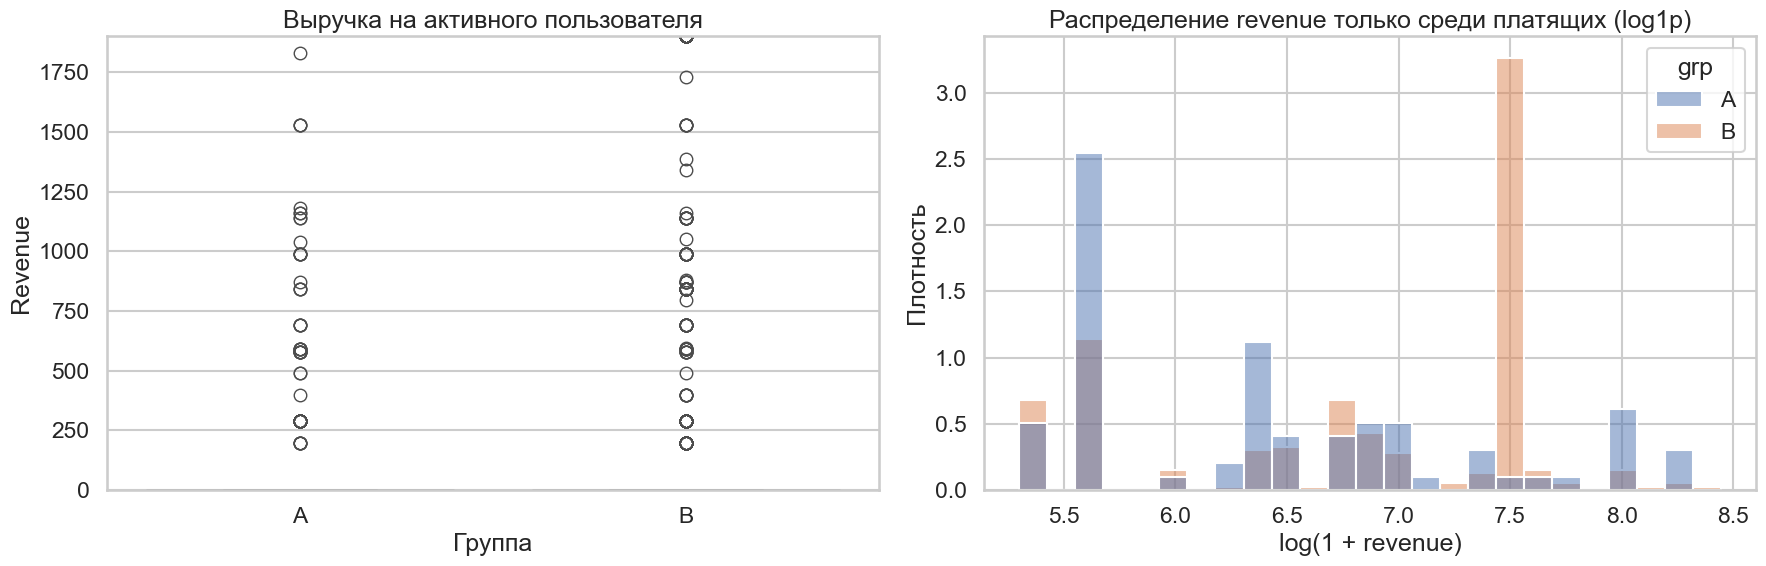

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=active_only_df, x="grp", y="revenue", ax=axes[0])
axes[0].set_title("Выручка на активного пользователя")
axes[0].set_xlabel("Группа")
axes[0].set_ylabel("Revenue")
axes[0].set_ylim(0, active_only_df["revenue"].quantile(0.99))

payers_only_df = active_only_df.query("is_paid == 1").copy()
sns.histplot(
    data=payers_only_df.assign(log_revenue=np.log1p(payers_only_df["revenue"])),
    x="log_revenue",
    hue="grp",
    bins=25,
    stat="density",
    common_norm=False,
    alpha=0.5,
    ax=axes[1],
)
axes[1].set_title("Распределение revenue только среди платящих (log1p)")
axes[1].set_xlabel("log(1 + revenue)")
axes[1].set_ylabel("Плотность")

plt.tight_layout()
plt.show()

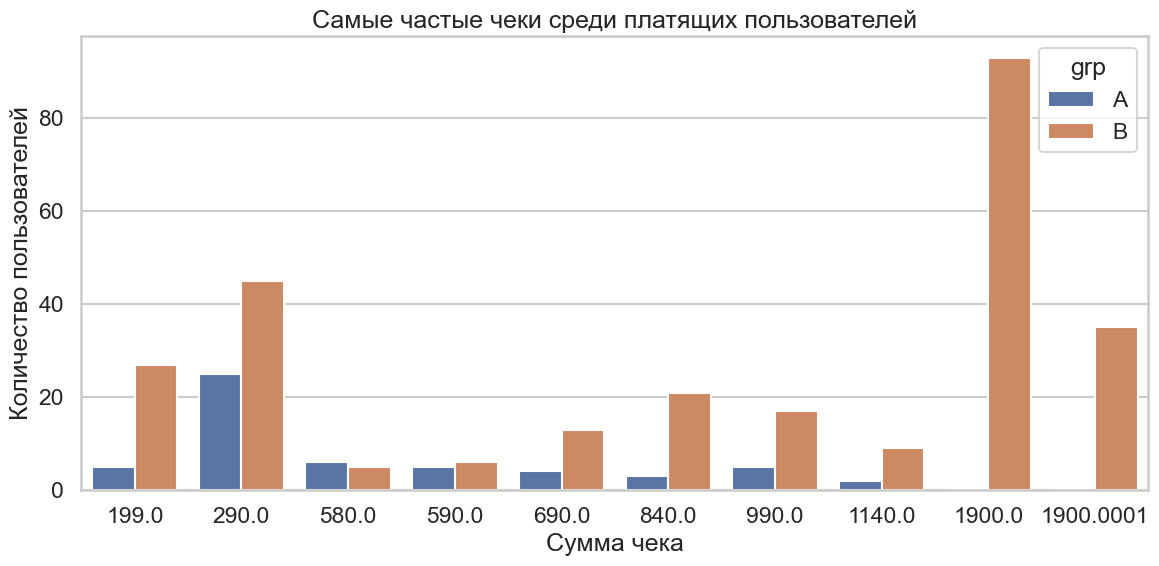

In [10]:
top_amounts = (
    payers_only_df.groupby(["grp", "revenue"], observed=False)
    .size()
    .reset_index(name="users")
)
top_amount_values = (
    top_amounts.groupby("revenue", observed=False)["users"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

top_amounts = top_amounts[top_amounts["revenue"].isin(top_amount_values)].copy()
top_amounts = top_amounts.sort_values(["revenue", "grp"])

plt.figure(figsize=(12, 6))
sns.barplot(data=top_amounts, x="revenue", y="users", hue="grp")
plt.title("Самые частые чеки среди платящих пользователей")
plt.xlabel("Сумма чека")
plt.ylabel("Количество пользователей")
plt.tight_layout()
plt.show()

In [11]:
amount_mix = (
    payers_only_df.groupby(["grp", "revenue"], observed=False)
    .size()
    .reset_index(name="users")
    .sort_values(["grp", "users"], ascending=[True, False])
    .groupby("grp")
    .head(5)
)

display(
    amount_mix.style
    .hide(axis="index")
    .format({"revenue": lambda x: format_money(x), "users": "{:,.0f}"})
)

grp,revenue,users
A,"290,00",25
A,"580,00",6
A,"199,00",5
A,"590,00",5
A,"990,00",5
B,"1 900,00",93
B,"290,00",45
B,"1 900,00",35
B,"199,00",27
B,"840,00",21


### Что видно на графиках

- В экспериментальной группе **B** платящих пользователей по доле не больше, чем в **A**.
- Зато среди платящих пользователей в **B** заметно выше средний чек.
- На графике сумм оплат появляется сильная концентрация чеков вокруг **1900**, которая практически отсутствует в группе **A**.

Это важная бизнес-подсказка: новая механика, возможно, не улучшает конверсию в саму оплату, 
но подталкивает к покупке более дорогого варианта / более высокого тарифа.

## 5. Ключевые метрики эксперимента

Для этого кейса логично смотреть на три метрики:

- **CR (Conversion Rate)** — доля активных пользователей, совершивших оплату;
- **ARPU** — средняя выручка на активного пользователя;
- **ARPPU** — средняя выручка на платящего пользователя.

Такой набор даёт более полную картину:
- `CR` отражает влияние на конверсию в оплату;
- `ARPU` показывает общий денежный эффект на пользователя;
- `ARPPU` отвечает на вопрос, стал ли выше средний чек у тех, кто всё-таки купил.

grp,users,payers,revenue,CR,ARPU,ARPPU
A,"1,538",78,"72 820,00","5,07%","47,35","933,59"
B,"6,803",314,"394 974,00","4,62%","58,06","1 257,88"


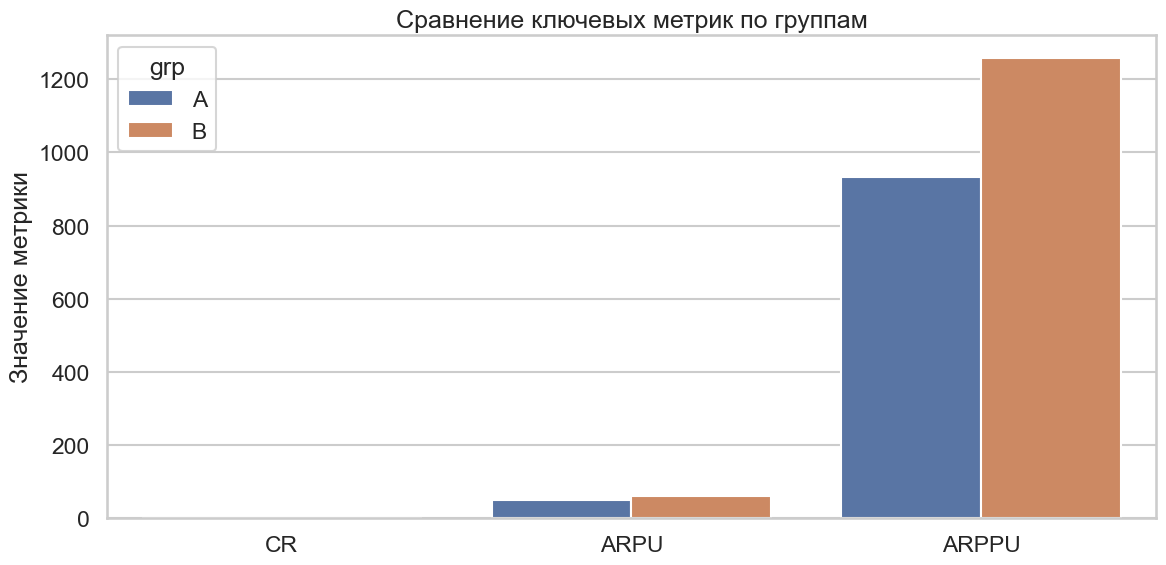

In [12]:
def calculate_ab_metrics(df: pd.DataFrame) -> pd.DataFrame:
    grouped = (
        df.groupby("grp", observed=False)
        .agg(
            users=("id", "nunique"),
            payers=("is_paid", "sum"),
            revenue=("revenue", "sum"),
        )
        .reset_index()
    )
    grouped["CR"] = grouped["payers"] / grouped["users"]
    grouped["ARPU"] = grouped["revenue"] / grouped["users"]
    grouped["ARPPU"] = grouped["revenue"] / grouped["payers"]
    return grouped

ab_metrics = calculate_ab_metrics(active_only_df)

metrics_long = (
    ab_metrics.melt(
        id_vars=["grp", "users", "payers", "revenue"],
        value_vars=["CR", "ARPU", "ARPPU"],
        var_name="metric",
        value_name="value",
    )
)

display(
    ab_metrics.style
    .hide(axis="index")
    .format(
        {
            "users": "{:,.0f}",
            "payers": "{:,.0f}",
            "revenue": lambda x: format_money(x),
            "CR": lambda x: format_percent(x),
            "ARPU": lambda x: format_money(x),
            "ARPPU": lambda x: format_money(x),
        }
    )
)

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_long, x="metric", y="value", hue="grp")
plt.title("Сравнение ключевых метрик по группам")
plt.xlabel("")
plt.ylabel("Значение метрики")
plt.tight_layout()
plt.show()

## 6. Проверка статистической значимости

### Почему здесь не стоит ограничиваться t-test
Платёжные данные почти всегда имеют тяжёлый хвост и избыток нулей.  
Поэтому для денежных метрик я использую **bootstrap для разности средних**, а для CR — **z-test для двух долей**.

### Гипотезы
Для каждой метрики:

- **H0**: различий между группами нет;
- **H1**: различия между группами есть.

In [13]:
def bootstrap_mean_diff(
    x: pd.Series | np.ndarray,
    y: pd.Series | np.ndarray,
    n_boot: int = 5_000,
    seed: int = RANDOM_STATE,
) -> tuple[np.ndarray, tuple[float, float], float]:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    rng = np.random.default_rng(seed)

    diffs = np.empty(n_boot)
    for i in range(n_boot):
        x_sample = rng.choice(x, size=len(x), replace=True)
        y_sample = rng.choice(y, size=len(y), replace=True)
        diffs[i] = y_sample.mean() - x_sample.mean()

    ci_low, ci_high = np.quantile(diffs, [0.025, 0.975])
    p_value = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    return diffs, (ci_low, ci_high), float(p_value)

a_df = active_only_df.query("grp == 'A'").copy()
b_df = active_only_df.query("grp == 'B'").copy()

# CR
cr_z_stat, cr_p_value = proportions_ztest(
    count=[a_df["is_paid"].sum(), b_df["is_paid"].sum()],
    nobs=[len(a_df), len(b_df)],
)
cr_ci = confint_proportions_2indep(
    count1=int(b_df["is_paid"].sum()),
    nobs1=len(b_df),
    count2=int(a_df["is_paid"].sum()),
    nobs2=len(a_df),
    method="newcomb",
)

# ARPU / ARPPU
arpu_boot, arpu_ci, arpu_p_value = bootstrap_mean_diff(a_df["revenue"], b_df["revenue"])
arppu_boot, arppu_ci, arppu_p_value = bootstrap_mean_diff(
    a_df.loc[a_df["is_paid"] == 1, "revenue"],
    b_df.loc[b_df["is_paid"] == 1, "revenue"],
)

test_results = pd.DataFrame(
    [
        {
            "Метрика": "CR",
            "A": a_df["is_paid"].mean(),
            "B": b_df["is_paid"].mean(),
            "Разница B - A": b_df["is_paid"].mean() - a_df["is_paid"].mean(),
            "95% CI (низ)": cr_ci[0],
            "95% CI (верх)": cr_ci[1],
            "p-value": cr_p_value,
        },
        {
            "Метрика": "ARPU",
            "A": a_df["revenue"].mean(),
            "B": b_df["revenue"].mean(),
            "Разница B - A": b_df["revenue"].mean() - a_df["revenue"].mean(),
            "95% CI (низ)": arpu_ci[0],
            "95% CI (верх)": arpu_ci[1],
            "p-value": arpu_p_value,
        },
        {
            "Метрика": "ARPPU",
            "A": a_df.loc[a_df["is_paid"] == 1, "revenue"].mean(),
            "B": b_df.loc[b_df["is_paid"] == 1, "revenue"].mean(),
            "Разница B - A": b_df.loc[b_df["is_paid"] == 1, "revenue"].mean() - a_df.loc[a_df["is_paid"] == 1, "revenue"].mean(),
            "95% CI (низ)": arppu_ci[0],
            "95% CI (верх)": arppu_ci[1],
            "p-value": arppu_p_value,
        },
    ]
)

display(
    test_results.style
    .hide(axis="index")
    .format(
        {
            "A": lambda x: format_percent(x) if x < 1 else format_money(x),
            "B": lambda x: format_percent(x) if x < 1 else format_money(x),
            "Разница B - A": lambda x: format_percent(x) if abs(x) < 1 else format_money(x),
            "95% CI (низ)": lambda x: format_percent(x) if abs(x) < 1 else format_money(x),
            "95% CI (верх)": lambda x: format_percent(x) if abs(x) < 1 else format_money(x),
            "p-value": "{:.4f}",
        }
    )
)

Метрика,A,B,Разница B - A,95% CI (низ),95% CI (верх),p-value
CR,"5,07%","4,62%","-0,46%","-1,76%","0,66%",0.4455
ARPU,"47,35","58,06","10,71","-6,60","26,31",0.2092
ARPPU,"933,59","1 257,88","324,29","94,37","542,69",0.0128


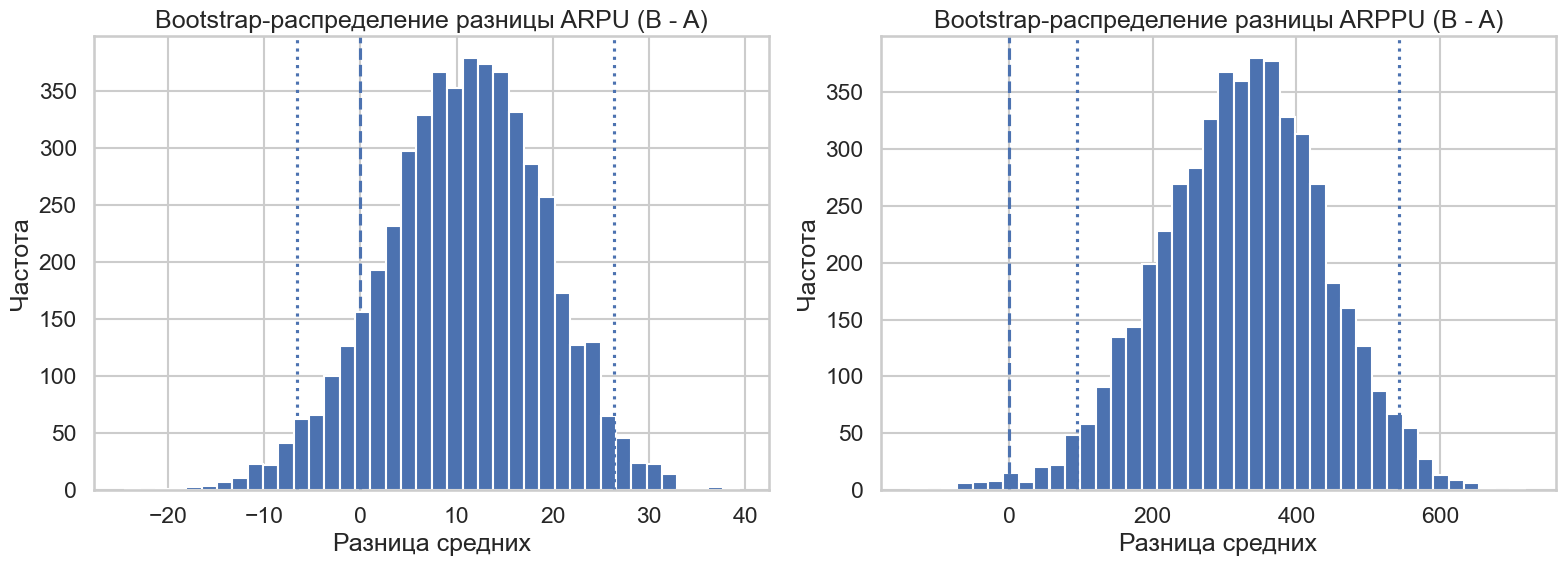

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(arpu_boot, bins=40)
axes[0].axvline(0, linestyle="--")
axes[0].axvline(arpu_ci[0], linestyle=":")
axes[0].axvline(arpu_ci[1], linestyle=":")
axes[0].set_title("Bootstrap-распределение разницы ARPU (B - A)")
axes[0].set_xlabel("Разница средних")
axes[0].set_ylabel("Частота")

axes[1].hist(arppu_boot, bins=40)
axes[1].axvline(0, linestyle="--")
axes[1].axvline(arppu_ci[0], linestyle=":")
axes[1].axvline(arppu_ci[1], linestyle=":")
axes[1].set_title("Bootstrap-распределение разницы ARPPU (B - A)")
axes[1].set_xlabel("Разница средних")
axes[1].set_ylabel("Частота")

plt.tight_layout()
plt.show()

In [15]:
cr_diff = b_df["is_paid"].mean() - a_df["is_paid"].mean()
arpu_diff = b_df["revenue"].mean() - a_df["revenue"].mean()
arppu_diff = (
    b_df.loc[b_df["is_paid"] == 1, "revenue"].mean()
    - a_df.loc[a_df["is_paid"] == 1, "revenue"].mean()
)

display(Markdown(
    f'''
<div class="note {'good' if arppu_p_value < 0.05 else 'warn'}">
<b>Итог по статистике.</b><br>
• <b>CR:</b> {format_percent(a_df["is_paid"].mean())} → {format_percent(b_df["is_paid"].mean())}, 
разница {format_percent(cr_diff)}, p-value = {cr_p_value:.4f}. Статистически значимого изменения не обнаружено.<br>
• <b>ARPU:</b> {format_money(a_df["revenue"].mean())} → {format_money(b_df["revenue"].mean())}, 
разница {format_money(arpu_diff)}, p-value = {arpu_p_value:.4f}. Точечный рост есть, но доверительный интервал включает 0.<br>
• <b>ARPPU:</b> {format_money(a_df.loc[a_df["is_paid"] == 1, "revenue"].mean())} → {format_money(b_df.loc[b_df["is_paid"] == 1, "revenue"].mean())}, 
разница {format_money(arppu_diff)}, p-value = {arppu_p_value:.4f}. Здесь рост статистически значим.
</div>
'''
))


<div class="note good">
<b>Итог по статистике.</b><br>
• <b>CR:</b> 5,07% → 4,62%, 
разница -0,46%, p-value = 0.4455. Статистически значимого изменения не обнаружено.<br>
• <b>ARPU:</b> 47,35 → 58,06, 
разница 10,71, p-value = 0.2092. Точечный рост есть, но доверительный интервал включает 0.<br>
• <b>ARPPU:</b> 933,59 → 1 257,88, 
разница 324,29, p-value = 0.0128. Здесь рост статистически значим.
</div>


## 7. Sensitivity-check: что будет, если считать по всем пользователям

Это не основной сценарий, потому что часть пользователей с оплатой не была активна в дни эксперимента.  
Но такой расчёт полезен как проверка устойчивости вывода.

In [16]:
def evaluate_scenario(df: pd.DataFrame, scenario_name: str) -> pd.DataFrame:
    a_local = df.query("grp == 'A'").copy()
    b_local = df.query("grp == 'B'").copy()

    _, cr_p = proportions_ztest(
        count=[a_local["is_paid"].sum(), b_local["is_paid"].sum()],
        nobs=[len(a_local), len(b_local)],
    )
    _, arpu_ci_local, arpu_p = bootstrap_mean_diff(a_local["revenue"], b_local["revenue"], n_boot=3000)
    _, arppu_ci_local, arppu_p = bootstrap_mean_diff(
        a_local.loc[a_local["is_paid"] == 1, "revenue"],
        b_local.loc[b_local["is_paid"] == 1, "revenue"],
        n_boot=3000,
    )

    return pd.DataFrame(
        [
            {
                "Сценарий": scenario_name,
                "CR_A": a_local["is_paid"].mean(),
                "CR_B": b_local["is_paid"].mean(),
                "p_CR": cr_p,
                "ARPU_A": a_local["revenue"].mean(),
                "ARPU_B": b_local["revenue"].mean(),
                "p_ARPU": arpu_p,
                "ARPPU_A": a_local.loc[a_local["is_paid"] == 1, "revenue"].mean(),
                "ARPPU_B": b_local.loc[b_local["is_paid"] == 1, "revenue"].mean(),
                "p_ARPPU": arppu_p,
            }
        ]
    )

sensitivity = pd.concat(
    [
        evaluate_scenario(active_only_df, "Только активные пользователи"),
        evaluate_scenario(experiment_df, "Все пользователи из групп"),
    ],
    ignore_index=True,
)

display(
    sensitivity.style
    .hide(axis="index")
    .format(
        {
            "CR_A": lambda x: format_percent(x),
            "CR_B": lambda x: format_percent(x),
            "p_CR": "{:.4f}",
            "ARPU_A": lambda x: format_money(x),
            "ARPU_B": lambda x: format_money(x),
            "p_ARPU": "{:.4f}",
            "ARPPU_A": lambda x: format_money(x),
            "ARPPU_B": lambda x: format_money(x),
            "p_ARPPU": "{:.4f}",
        }
    )
)

Сценарий,CR_A,CR_B,p_CR,ARPU_A,ARPU_B,p_ARPU,ARPPU_A,ARPPU_B,p_ARPPU
Только активные пользователи,"5,07%","4,62%",0.4455,"47,35","58,06",0.2100,"933,59","1 257,88",0.0133
Все пользователи из групп,"0,73%","0,72%",0.9644,"6,27","8,04",0.0713,"860,71","1 108,82",0.0067


### Вывод из sensitivity-check
Картина не меняется по сути:

- **CR** остаётся без значимых различий;
- **ARPU** выглядит выше в группе **B**, но эффект нестабилен;
- **ARPPU** стабильно выше в тесте.

Значит, ключевой инсайт сохраняется:  
**новая механика скорее повышает средний чек, чем улучшает конверсию в оплату.**

## 8. Финальная бизнес-рекомендация

<div class="note warn">
<b>Рекомендация:</b> я бы <b>не выкатывал новую механику сразу на 100% аудитории</b>.<br><br>
Причина проста: у нас есть убедительный рост <b>ARPPU</b>, но нет статистически надёжного роста <b>ARPU</b>, 
а по <b>CR</b> наблюдается даже небольшое отрицательное смещение.<br><br>
Практически это выглядит так: новая механика помогает зарабатывать больше <i>на тех, кто уже купил</i>, 
но не доказывает, что помогает зарабатывать больше <i>на каждом активном пользователе</i>.
</div>

### Что бы я предложил дальше
1. Запустить **поэтапный rollout** на части трафика, а не на всей аудитории сразу.  
2. Поставить **guardrail-метрику по CR**, чтобы не ухудшить воронку оплаты.  
3. Разобрать, почему в группе **B** так часто встречается чек **1900** — это очень сильный продуктовый сигнал.  
4. Повторить тест на большем горизонте или на сегментах, где ожидается более высокий средний чек.

---

# Задание 2. SQL

Ниже — аккуратно оформленные SQL-решения по обоим подпунктам.  
Синтаксис ориентирован на **ClickHouse**.

## 2.1. Очень усердные ученики

**Задача:** посчитать число студентов, которые за текущий месяц хотя бы раз решили **20 и более** горошин правильно.

```sql
SELECT count() AS diligent_students
FROM
(
    SELECT st_id
    FROM default.peas
    WHERE correct = 1
      AND timest >= toStartOfMonth(now())
      AND timest < addMonths(toStartOfMonth(now()), 1)
    GROUP BY st_id
    HAVING count() >= 20
);
```

**Почему запрос хороший:**
- фильтрация по месяцу и правильным ответам происходит **до агрегации**;
- считаем только нужные строки;
- на внешнем уровне остаётся только финальный `count()`.

## 2.2. Оптимизация воронки

**Нужно в одном запросе получить по группам:**
- `ARPU`
- `ARPAU`
- `CR`
- `CR_active`
- `CR_math`

```sql
WITH active_flags AS
(
    SELECT
        st_id,
        countIf(correct = 1) > 10 AS active_in_total,
        countIf(correct = 1 AND subject = 'math') >= 2 AS active_in_math
    FROM default.peas
    GROUP BY st_id
),
sales AS
(
    SELECT
        st_id,
        sum(money) AS revenue,
        count() > 0 AS paid_any,
        countIf(subject = 'math') > 0 AS paid_math
    FROM default.final_project_check
    GROUP BY st_id
)
SELECT
    s.test_grp,
    round(sum(ifNull(sl.revenue, 0)) / count(), 2) AS ARPU,
    round(sum(ifNull(sl.revenue, 0)) / sum(ifNull(af.active_in_total, 0)), 2) AS ARPAU,
    round(sum(if(ifNull(sl.paid_any, 0) = 1, 1, 0)) / count(), 4) AS CR,
    round(
        sum(if(ifNull(af.active_in_total, 0) = 1 AND ifNull(sl.paid_any, 0) = 1, 1, 0))
        / sum(ifNull(af.active_in_total, 0)),
        4
    ) AS CR_active,
    round(
        sum(if(ifNull(af.active_in_math, 0) = 1 AND ifNull(sl.paid_math, 0) = 1, 1, 0))
        / sum(ifNull(af.active_in_math, 0)),
        4
    ) AS CR_math
FROM default.studs AS s
LEFT JOIN active_flags AS af USING (st_id)
LEFT JOIN sales AS sl USING (st_id)
GROUP BY s.test_grp
ORDER BY s.test_grp;
```

### Логика решения
- `active_flags` заранее строит флаги «активный вообще» и «активный по математике»;
- `sales` агрегирует покупки до уровня пользователя;
- финальный `SELECT` считает все необходимые метрики **в одном проходе по группам**.

---

# Задание 3. Python

Ниже — более аккуратная реализация двух функций:

1. автоматическая загрузка дополнительного файла `groups_add.csv` c **произвольными заголовками**;
2. пересчёт метрик после обновления;
3. функция визуализации результатов.

In [17]:
def load_group_update(path_or_url: str | Path) -> pd.DataFrame:
    df = pd.read_csv(path_or_url, sep=None, engine="python")
    return normalize_additional_groups(df)

def recalculate_metrics_with_updates(
    groups_df: pd.DataFrame,
    active_df: pd.DataFrame,
    checks_df: pd.DataFrame,
    update_sources: str | Path | list[str | Path] | None = None,
    active_only: bool = True,
) -> pd.DataFrame:
    if update_sources is None:
        update_sources = []
    elif isinstance(update_sources, (str, Path)):
        update_sources = [update_sources]

    history = []
    current_groups = groups_df.copy()

    for step, source in enumerate([None] + list(update_sources)):
        if step > 0:
            update_df = load_group_update(source)
            current_groups = (
                pd.concat([current_groups, update_df], ignore_index=True)
                .drop_duplicates("id", keep="last")
            )

        current_experiment = prepare_experiment_dataset(current_groups, active_df, checks_df)
        if active_only:
            current_experiment = current_experiment.query("is_active == 1").copy()

        metrics = calculate_ab_metrics(current_experiment)
        metrics["step"] = step
        history.append(metrics)

    return pd.concat(history, ignore_index=True)

metrics_history = recalculate_metrics_with_updates(
    groups_df=groups,
    active_df=active_studs,
    checks_df=checks,
    update_sources=[groups_add_path],
    active_only=True,
)

display(
    metrics_history.style
    .hide(axis="index")
    .format(
        {
            "users": "{:,.0f}",
            "payers": "{:,.0f}",
            "revenue": lambda x: format_money(x),
            "CR": lambda x: format_percent(x),
            "ARPU": lambda x: format_money(x),
            "ARPPU": lambda x: format_money(x),
            "step": "{:,.0f}",
        }
    )
)

grp,users,payers,revenue,CR,ARPU,ARPPU,step
A,"1,535",78,"72 820,00","5,08%","47,44","933,59",0
B,"6,793",313,"393 074,00","4,61%","57,86","1 255,83",0
A,"1,538",78,"72 820,00","5,07%","47,35","933,59",1
B,"6,803",314,"394 974,00","4,62%","58,06","1 257,88",1


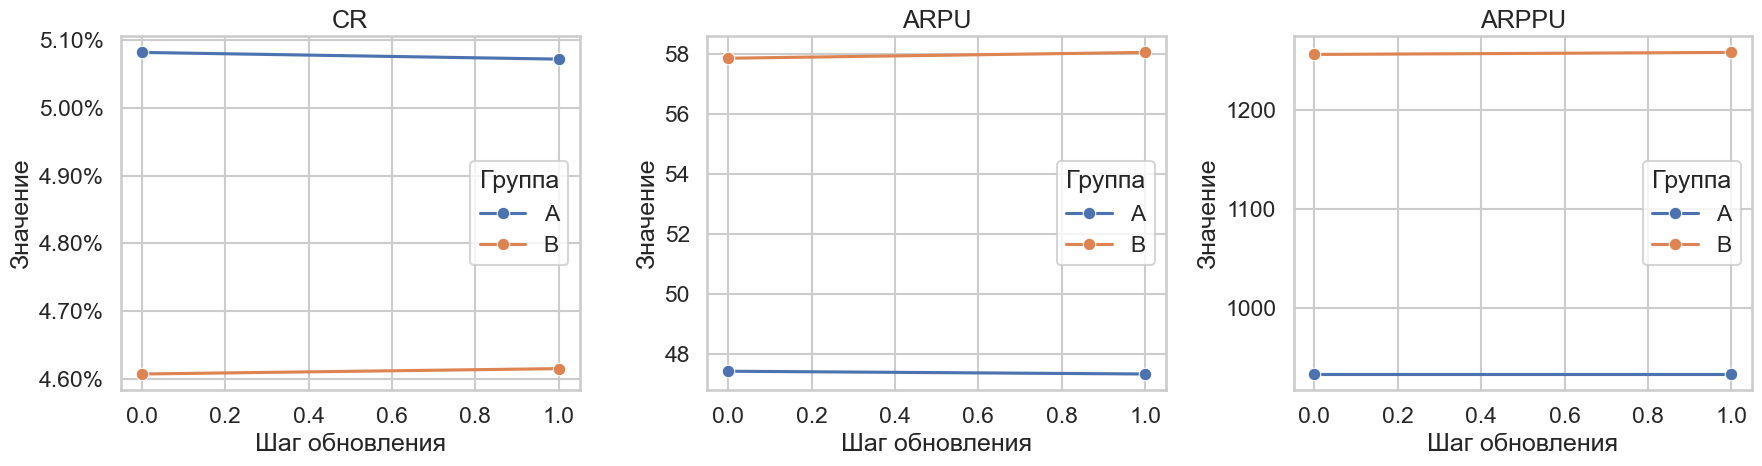

In [18]:
def plot_metrics_history(metrics_history: pd.DataFrame) -> None:
    plot_df = metrics_history.melt(
        id_vars=["step", "grp"],
        value_vars=["CR", "ARPU", "ARPPU"],
        var_name="metric",
        value_name="value",
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    for ax, metric_name in zip(axes, ["CR", "ARPU", "ARPPU"]):
        subset = plot_df.query("metric == @metric_name")
        sns.lineplot(data=subset, x="step", y="value", hue="grp", marker="o", ax=ax)
        ax.set_title(metric_name)
        ax.set_xlabel("Шаг обновления")
        ax.set_ylabel("Значение")
        if metric_name == "CR":
            ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
        ax.legend(title="Группа")

    plt.tight_layout()
    plt.show()

plot_metrics_history(metrics_history)

### Что видно по автоматическому пересчёту
После добавления `groups_add` значения меняются **минимально**.  
Это хороший признак: основные выводы исследования устойчивы и не зависят от маленького догруженного файла.

# Итог

В результате получился ноутбук в формате полноценного аналитического отчёта:

- с понятной структурой;
- с прозрачным data QA;
- с аккуратной бизнес-логикой формирования выборки;
- с честной статистической проверкой;
- с оформленными SQL-решениями;
- с функциями для переиспользования и обновления данных.

<div class="note good">
<b>Главный вывод:</b> новая механика не доказывает рост конверсии, но даёт сильный сигнал на рост среднего чека среди платящих пользователей. 
Это хороший кандидат для поэтапного rollout и дополнительного тестирования, но не для безусловного запуска на всю аудиторию.
</div>